<a href="https://colab.research.google.com/github/sammy495/ML_Experiment_/blob/main/Experiment_2_ML_practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 2

**Name:** samiksha kenvadekar
**Roll No:** Ce15

## Aim

To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

## Theory

Linear regression models the relationship between a target continuous variable $Y$ and an input feature vector $X$ using a linear equation:

$$
\hat{y} = w_0 + w_1x_1
$$

where:

- $\hat{y}$ = predicted value of the target variable
- $w_0$ = intercept or bias term
- $w_1$ = weight or coefficient
- $x_1$ = input feature

In matrix form, including the bias/intercept term:

$$
\hat{y} = Xw
$$

where $X$ is the input feature matrix, $w$ is the weight vector, and $\hat{y}$ is the predicted output vector.

To find the optimal weight vector $\hat{w}$, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values $y$ and predicted values $\hat{y}$:

$$
SSE = \sum_{i=1}^{N}(y_i - \hat{y}_i)^2
$$

In matrix form:

$$
SSE = (y - Xw)^T(y - Xw)
$$

Solving for $\hat{w}$ analytically yields the normal equation:

$$
\hat{w} = (X^T X)^{-1}X^T y
$$

The inverse $(X^T X)^{-1}$ exists only if the matrix is non-singular, i.e., its determinant is non-zero.

For the given experiment, Simple Linear Regression is used to predict MPG from Horsepower. Therefore, the regression equation can be represented as:

$$
\widehat{MPG} = w_0 + w_1 \times Horsepower
$$

The performance of the regression model can be evaluated using metrics such as SSE, MSE, and $R^2$.

### Sum of Squared Errors (SSE)

$$
SSE = \sum_{i=1}^{N}(y_i - \hat{y}_i)^2
$$

SSE measures the squared difference between the actual and predicted values.

### Mean Squared Error (MSE)

$$
MSE = \frac{SSE}{N}
$$

MSE represents the average squared error between the actual and predicted values.

### R-Squared ($R^2$)

$$
R^2 = 1 - \frac{SSE}{SST}
$$

where:

- $SSE$ = Sum of Squared Errors
- $SST$ = Total Sum of Squares

$R^2$ indicates how well the regression model explains the variation in the target variable.

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

In [ ]:
# Upload and load the Auto MPG dataset

from google.colab import files

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("Auto MPG dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

display(df.head())

Saving auto-mpg.csv to auto-mpg.csv
Auto MPG dataset loaded successfully.
Dataset shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [ ]:
# Inspect the dataset

print("Dataset Shape:")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
Rows    : 398
Columns : 9

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB

Statistical Summary:


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [ ]:
# Select Horsepower and MPG and clean the dataset

data = df[["horsepower", "mpg"]].copy()

# Convert Horsepower to numeric and replace invalid values such as '?' with NaN
data["horsepower"] = pd.to_numeric(data["horsepower"], errors="coerce")

# Remove rows containing missing or invalid values
data = data.dropna()

# Reset the index after cleaning
data = data.reset_index(drop=True)

print("Cleaned Dataset Shape:")
print(f"Rows    : {data.shape[0]}")
print(f"Columns : {data.shape[1]}")

print("\nData Types:")
print(data.dtypes)

print("\nFirst 10 rows of cleaned data:")
display(data.head(10))

Cleaned Dataset Shape:
Rows    : 392
Columns : 2

Data Types:
horsepower    float64
mpg           float64
dtype: object

First 10 rows of cleaned data:


,horsepower,mpg
0,130.0,18.0
1,165.0,15.0
2,150.0,18.0
3,150.0,16.0
4,140.0,17.0
5,198.0,15.0
6,220.0,14.0
7,215.0,14.0
8,225.0,14.0
9,190.0,15.0


In [ ]:
# Check for missing values

missing_values = data.isnull().sum()

print("Missing Values:")
display(missing_values.to_frame(name="Number of Missing Values"))

print(f"Total Missing Values: {missing_values.sum()}")

Missing Values:


,Number of Missing Values
horsepower,0
mpg,0


Total Missing Values: 0


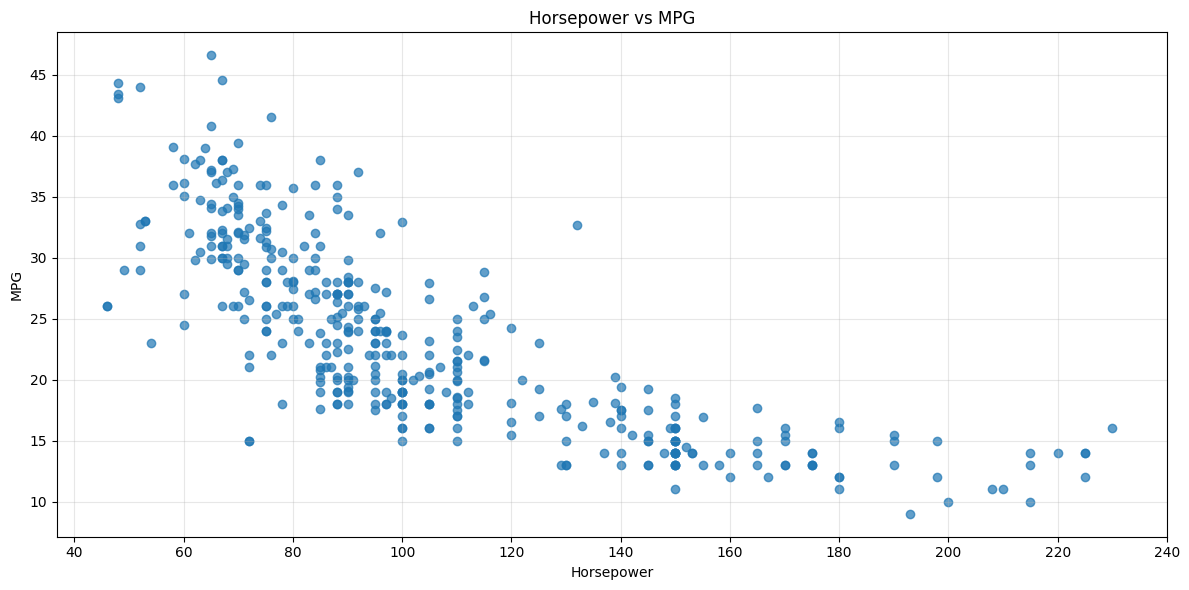

In [ ]:
# Plot the relationship between Horsepower and MPG

plt.figure(figsize=(12, 6))

plt.scatter(
    data["horsepower"],
    data["mpg"],
    alpha=0.7
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")

# Set a reasonable number of X-axis tick marks
plt.xticks(np.arange(40, 250, 20))

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
# Prepare the independent variable X and dependent variable y

X = data["horsepower"].values
y = data["mpg"].values

print("Number of observations:", len(X))

print("\nFirst 5 Horsepower values:")
print(X[:5])

print("\nFirst 5 MPG values:")
print(y[:5])

Number of observations: 392

First 5 Horsepower values:
[130. 165. 150. 150. 140.]

First 5 MPG values:
[18. 15. 18. 16. 17.]


In [ ]:
# Add the bias/intercept term to the X matrix

bias = np.ones(len(X))

X_matrix = np.column_stack((bias, X))

print("X Matrix Shape:", X_matrix.shape)

print("\nFirst 10 rows of X matrix:")
print(X_matrix[:10])

X Matrix Shape: (392, 2)

First 10 rows of X matrix:
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]
 [  1. 198.]
 [  1. 220.]
 [  1. 215.]
 [  1. 225.]
 [  1. 190.]]


In [ ]:
# Calculate the correlation between Horsepower and MPG

correlation = data["horsepower"].corr(data["mpg"])

print(f"Correlation between Horsepower and MPG: {correlation:.4f}")

if correlation < 0:
    print("Interpretation: Horsepower and MPG have a negative relationship.")
elif correlation > 0:
    print("Interpretation: Horsepower and MPG have a positive relationship.")
else:
    print("Interpretation: There is no linear correlation.")

Correlation between Horsepower and MPG: -0.7784
Interpretation: Horsepower and MPG have a negative relationship.


In [ ]:
# Calculate OLS weights using the normal equation

X_transpose = X_matrix.T

XTX = X_transpose @ X_matrix

XTX_inverse = np.linalg.inv(XTX)

XTy = X_transpose @ y

w = XTX_inverse @ XTy

w0 = w[0]
w1 = w[1]

print("OLS Coefficients")
print("-" * 30)
print(f"Intercept (w0): {w0:.6f}")
print(f"Slope     (w1): {w1:.6f}")

OLS Coefficients
------------------------------
Intercept (w0): 39.935861
Slope     (w1): -0.157845


In [ ]:
# Display the Simple Linear Regression equation

print("Simple Linear Regression Equation")
print("-" * 40)

print(f"Predicted MPG = {w0:.4f} + ({w1:.4f} × Horsepower)")

print("\nInterpretation:")
print(f"For every 1-unit increase in Horsepower, predicted MPG changes by approximately {w1:.4f}.")

Simple Linear Regression Equation
----------------------------------------
Predicted MPG = 39.9359 + (-0.1578 × Horsepower)

Interpretation:
For every 1-unit increase in Horsepower, predicted MPG changes by approximately -0.1578.


In [ ]:
# Predict MPG values using the calculated OLS weights

y_pred = X_matrix @ w

data["Predicted_MPG"] = y_pred

print("Actual vs Predicted MPG")
print("-" * 60)

display(
    data[["horsepower", "mpg", "Predicted_MPG"]].head(10)
)

Actual vs Predicted MPG
------------------------------------------------------------


,horsepower,mpg,Predicted_MPG
0,130.0,18.0,19.416046
1,165.0,15.0,13.891480
2,150.0,18.0,16.259151
3,150.0,16.0,16.259151
4,140.0,17.0,17.837598
5,198.0,15.0,8.682604
6,220.0,14.0,5.210020
7,215.0,14.0,5.999243
8,225.0,14.0,4.420796
9,190.0,15.0,9.945362


In [ ]:
# Calculate the residuals

residuals = y - y_pred

data["Residual"] = residuals

print("Actual, Predicted and Residual Values")
print("-" * 80)

display(
    data[["horsepower", "mpg", "Predicted_MPG", "Residual"]].head(10)
)

Actual, Predicted and Residual Values
--------------------------------------------------------------------------------


,horsepower,mpg,Predicted_MPG,Residual
0,130.0,18.0,19.416046,-1.416046
1,165.0,15.0,13.891480,1.108520
2,150.0,18.0,16.259151,1.740849
3,150.0,16.0,16.259151,-0.259151
4,140.0,17.0,17.837598,-0.837598
5,198.0,15.0,8.682604,6.317396
6,220.0,14.0,5.210020,8.789980
7,215.0,14.0,5.999243,8.000757
8,225.0,14.0,4.420796,9.579204
9,190.0,15.0,9.945362,5.054638


In [ ]:
# Calculate Sum of Squared Errors (SSE)

SSE = np.sum((y - y_pred) ** 2)

print("Sum of Squared Errors (SSE)")
print("-" * 35)
print(f"SSE = {SSE:.6f}")

Sum of Squared Errors (SSE)
-----------------------------------
SSE = 9385.915872


In [ ]:
# Calculate Mean Squared Error (MSE)

N = len(y)

MSE = SSE / N

print("Mean Squared Error (MSE)")
print("-" * 35)
print(f"Number of observations (N): {N}")
print(f"MSE = {MSE:.6f}")

Mean Squared Error (MSE)
-----------------------------------
Number of observations (N): 392
MSE = 23.943663


In [ ]:
# Calculate R-squared (R²)

SST = np.sum((y - np.mean(y)) ** 2)

R2 = 1 - (SSE / SST)

print("R-Squared (R²)")
print("-" * 35)
print(f"SST = {SST:.6f}")
print(f"R²  = {R2:.6f}")

R-Squared (R²)
-----------------------------------
SST = 23818.993469
R²  = 0.605948


In [ ]:
# Display all model evaluation results

print("=" * 50)
print("         MODEL EVALUATION RESULTS")
print("=" * 50)

print(f"Intercept (w0) : {w0:.6f}")
print(f"Slope (w1)     : {w1:.6f}")

print(f"\nSSE            : {SSE:.6f}")
print(f"MSE            : {MSE:.6f}")
print(f"R²             : {R2:.6f}")

print("=" * 50)

         MODEL EVALUATION RESULTS
Intercept (w0) : 39.935861
Slope (w1)     : -0.157845

SSE            : 9385.915872
MSE            : 23.943663
R²             : 0.605948


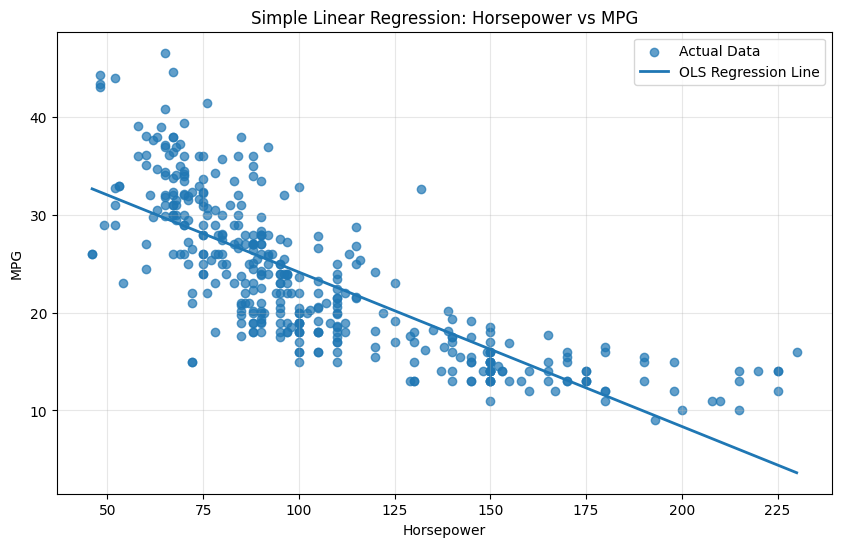

In [ ]:
# Plot the Simple Linear Regression line

plt.figure(figsize=(10, 6))

plt.scatter(
    data["horsepower"],
    data["mpg"],
    alpha=0.7,
    label="Actual Data"
)

sorted_data = data.sort_values("horsepower")

plt.plot(
    sorted_data["horsepower"],
    sorted_data["Predicted_MPG"],
    linewidth=2,
    label="OLS Regression Line"
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression: Horsepower vs MPG")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

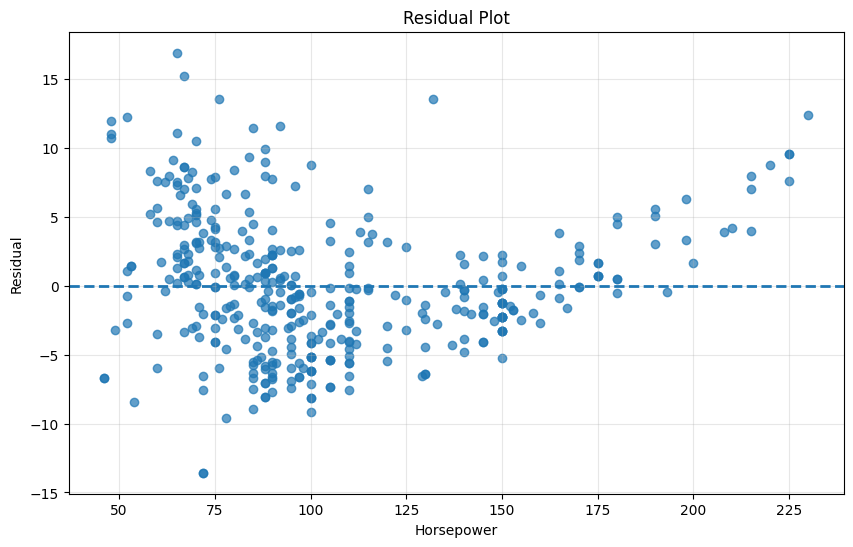

In [ ]:
# Plot the residuals

plt.figure(figsize=(10, 6))

plt.scatter(
    data["horsepower"],
    data["Residual"],
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Horsepower")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# Display actual MPG, predicted MPG and residual values

comparison = data[
    ["horsepower", "mpg", "Predicted_MPG", "Residual"]
].copy()

comparison.columns = [
    "Horsepower",
    "Actual MPG",
    "Predicted MPG",
    "Residual"
]

print("Actual vs Predicted MPG")
print("-" * 80)

display(comparison.head(15))

Actual vs Predicted MPG
--------------------------------------------------------------------------------


,Horsepower,Actual MPG,Predicted MPG,Residual
0,130.0,18.0,19.416046,-1.416046
1,165.0,15.0,13.891480,1.108520
2,150.0,18.0,16.259151,1.740849
3,150.0,16.0,16.259151,-0.259151
4,140.0,17.0,17.837598,-0.837598
5,198.0,15.0,8.682604,6.317396
6,220.0,14.0,5.210020,8.789980
7,215.0,14.0,5.999243,8.000757
8,225.0,14.0,4.420796,9.579204
9,190.0,15.0,9.945362,5.054638


In [ ]:
# Predict MPG for a new Horsepower value

horsepower_input = 150

predicted_mpg = w0 + w1 * horsepower_input

print("=" * 45)
print("       NEW MPG PREDICTION")
print("=" * 45)

print(f"Input Horsepower : {horsepower_input}")
print(f"Predicted MPG    : {predicted_mpg:.2f}")

print("=" * 45)

       NEW MPG PREDICTION
Input Horsepower : 150
Predicted MPG    : 16.26


In [ ]:
# Display the final interpretation of the experiment

print("=" * 65)
print("                 EXPERIMENT INTERPRETATION")
print("=" * 65)

print(f"\n1. Correlation between Horsepower and MPG: {correlation:.4f}")

if correlation < 0:
    print("   There is a negative relationship between Horsepower and MPG.")
else:
    print("   There is a positive relationship between Horsepower and MPG.")

print("\n2. Regression Equation:")
print(f"   Predicted MPG = {w0:.4f} + ({w1:.4f} × Horsepower)")

print("\n3. Model Evaluation:")
print(f"   SSE = {SSE:.4f}")
print(f"   MSE = {MSE:.4f}")
print(f"   R²  = {R2:.4f}")

print("\n4. R² Interpretation:")
print(f"   The model explains approximately {R2 * 100:.2f}% of the variation in MPG.")

print("\n5. Overall Result:")
print("   Horsepower shows a negative relationship with MPG.")
print("   The OLS method was successfully used to fit the Simple Linear Regression model.")

print("=" * 65)

                 EXPERIMENT INTERPRETATION

1. Correlation between Horsepower and MPG: -0.7784
   There is a negative relationship between Horsepower and MPG.

2. Regression Equation:
   Predicted MPG = 39.9359 + (-0.1578 × Horsepower)

3. Model Evaluation:
   SSE = 9385.9159
   MSE = 23.9437
   R²  = 0.6059

4. R² Interpretation:
   The model explains approximately 60.59% of the variation in MPG.

5. Overall Result:
   Horsepower shows a negative relationship with MPG.
   The OLS method was successfully used to fit the Simple Linear Regression model.
